# Forecast Using the TiRex Family



TimeCopilot ships a single `TiRex` class that transparently supports both TiRex 1.0 and TiRex 2.0 foundation models from NX-AI. Pass the Hugging Face `repo_id` to select the checkpoint:

- **TiRex 1.0** (`NX-AI/TiRex`): univariate zero-shot forecasting with xLSTM.
- **TiRex 2.0** (`NX-AI/TiRex-2`): extends TiRex to multivariate forecasting and covariates (this notebook uses the univariate API).

*Requirements*:

    - Python >= 3.11
    - TiRex 1.0 runs on CPU and CUDA (including macOS).
    - TiRex 2.0 runs on CPU, CUDA, and Apple MPS. On CUDA it uses Triton kernels for speed; on CPU and MPS it uses native PyTorch kernels (no Triton required).

In this example we compare TiRex 1.0 and TiRex 2.0 against the classical baselines `Prophet`, `AutoARIMA`, and `SeasonalNaive` on event pageview data.



## Import libraries



In [26]:
import sys

import pandas as pd

from timecopilot import TimeCopilotForecaster

if sys.version_info < (3, 11):
    raise RuntimeError("TiRex requires Python >= 3.11")


## Load the dataset

The DataFrame must include at least the following columns:
- unique_id: Unique identifier for each time series (string)
- ds: Date column (datetime format)
- y: Target variable for forecasting (float format)

The pandas frequency will be inferred from the ds column, if not provided.
If the seasonality is not provided, it will be inferred based on the frequency.
If the horizon is not set, it will default to 2 times the inferred seasonality.



In [27]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()


,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Plot the data



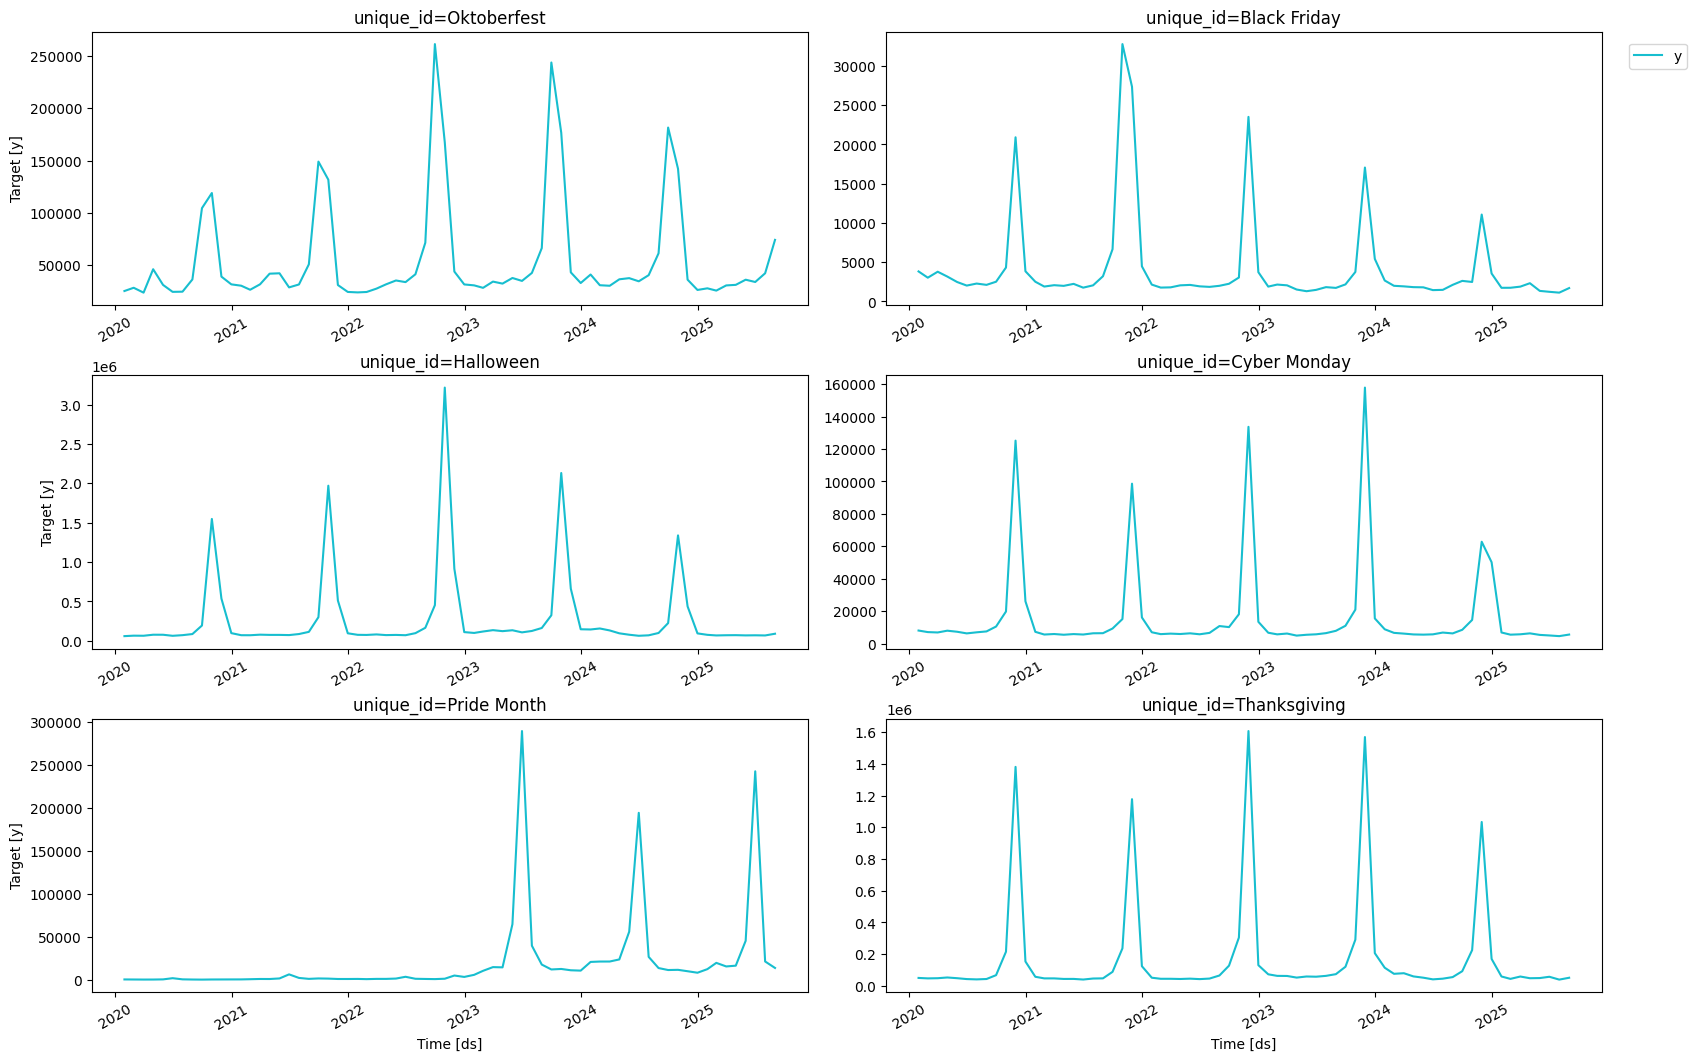

In [28]:
TimeCopilotForecaster.plot(df)


## Import the models



In [29]:
from timecopilot.models.foundation.tirex import TiRex
from timecopilot.models.prophet import Prophet
from timecopilot.models.stats import AutoARIMA, SeasonalNaive


## Create a TimeCopilotForecaster

We compare TiRex 1.0 (`NX-AI/TiRex`) with TiRex 2.0 (`NX-AI/TiRex-2`) against `Prophet`, `AutoARIMA`, and `SeasonalNaive`. Each model gets a distinct `alias` so its forecasts are easy to identify.



In [30]:
models = [
    TiRex(repo_id="NX-AI/TiRex", alias="NX-AI/TiRex"),
    TiRex(repo_id="NX-AI/TiRex-2", alias="NX-AI/TiRex-2"),
    Prophet(),
    AutoARIMA(),
    SeasonalNaive(),
]

tcf = TimeCopilotForecaster(models=models)


## Generate forecast

You can optionally specify the following parameters:
- freq: The frequency of your data (e.g., 'D' for daily, 'M' for monthly)
- h: The forecast horizon, which is the number of periods to predict
- seasonality: The seasonal period of your data, which can be inferred if not provided



In [ ]:
level = [0, 20, 40, 60, 80] # we need to pass 0 level since specific quantiles are required by TiRex
cv_df = tcf.cross_validation(df=df, h=12, level=level)


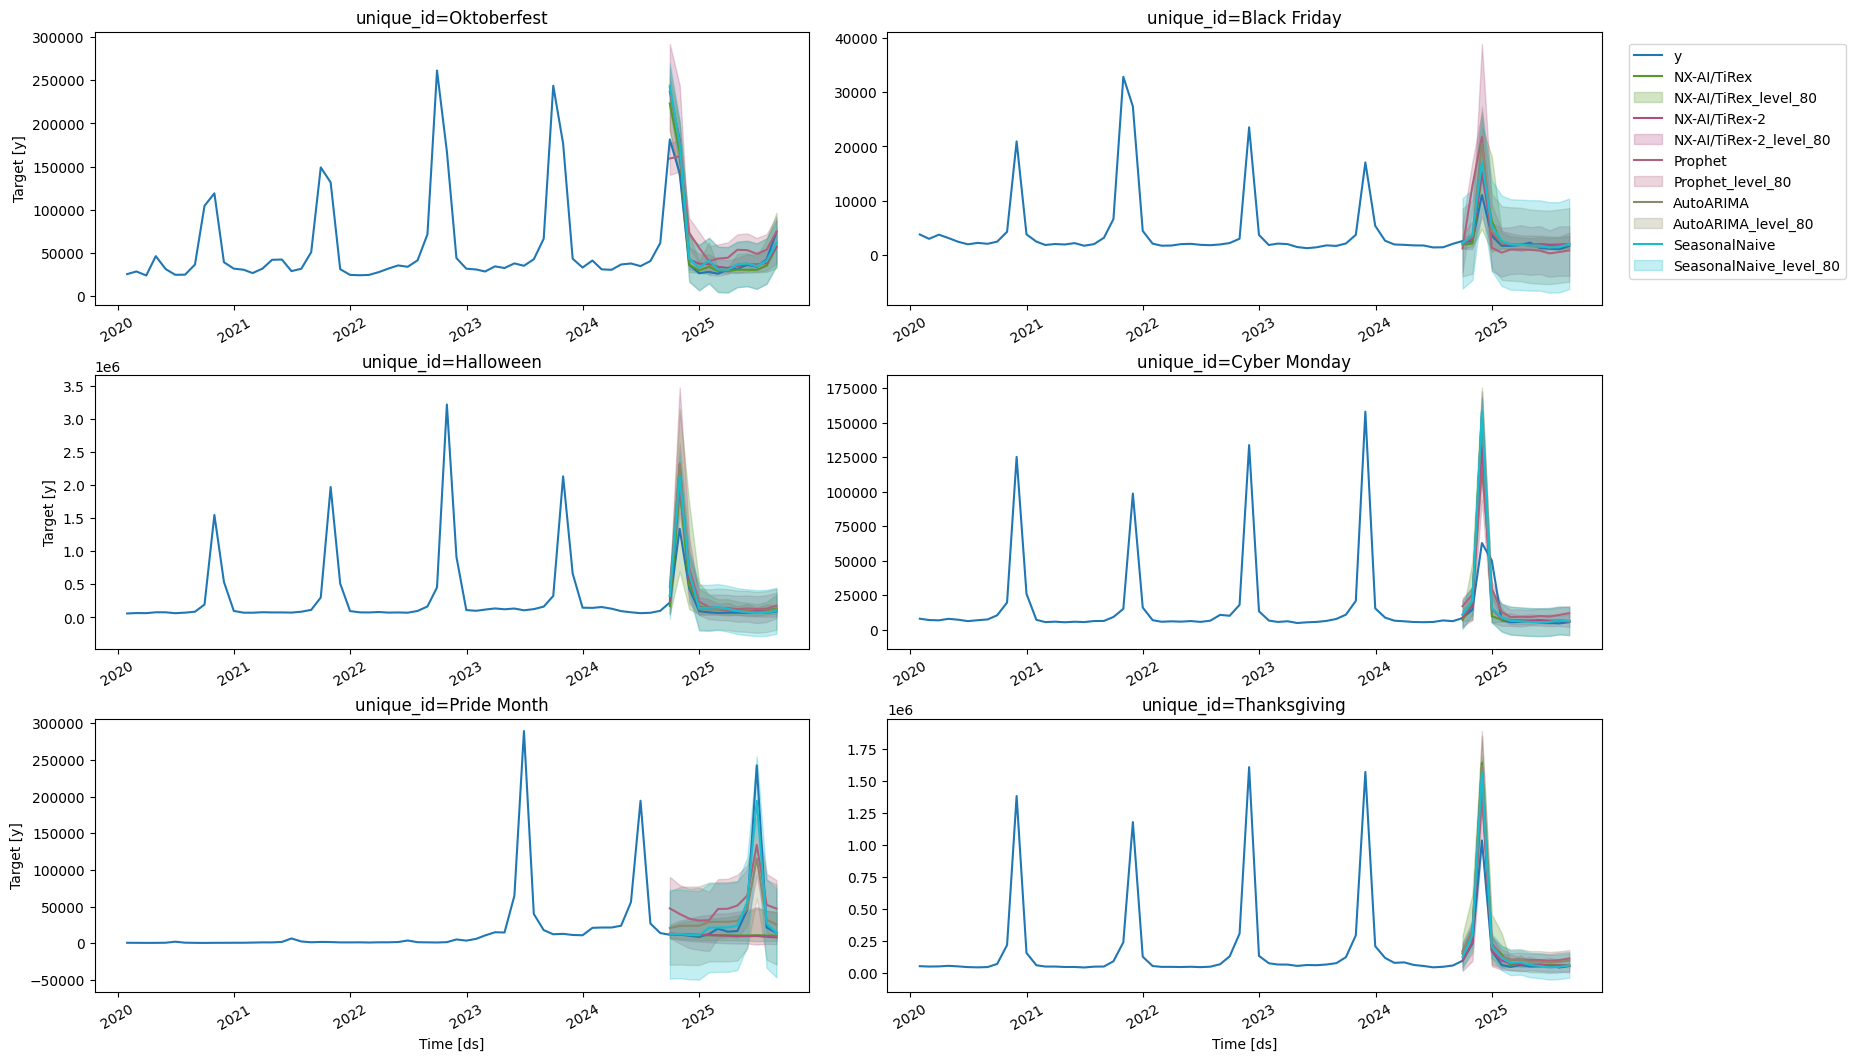

In [32]:
tcf.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[80])


In [33]:
cv_df.head()


,unique_id,ds,cutoff,y,NX-AI/TiRex,NX-AI/TiRex-lo-0,NX-AI/TiRex-hi-0,NX-AI/TiRex-lo-20,NX-AI/TiRex-hi-20,NX-AI/TiRex-lo-40,...,SeasonalNaive-lo-0,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-hi-0,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80
0,Black Friday,2024-09-30,2024-08-31,2607,1948.827637,1948.827637,1948.827637,1792.236816,2103.256836,1641.902100,...,2160.0,518.105774,-1238.539673,-3294.386475,-6145.491211,2160.0,3801.894287,5558.539551,7614.386719,10465.491211
1,Black Friday,2024-10-31,2024-08-31,2470,2139.354004,2139.354004,2139.354004,2028.763184,2318.608643,1966.871338,...,3746.0,2104.105713,347.460358,-1708.386597,-4559.491211,3746.0,5387.894043,7144.539551,9200.386719,12051.491211
2,Black Friday,2024-11-30,2024-08-31,11058,14991.896484,14991.896484,14991.896484,13052.220703,16615.169922,10291.545898,...,17053.0,15411.105469,13654.459961,11598.613281,8747.508789,17053.0,18694.894531,20451.539062,22507.386719,25358.490234
3,Black Friday,2024-12-31,2024-08-31,3548,6324.091797,6324.091797,6324.091797,4324.829590,8167.489258,2777.518311,...,5407.0,3765.105713,2008.460327,-47.386593,-2898.491211,5407.0,7048.894043,8805.540039,10861.386719,13712.491211
4,Black Friday,2025-01-31,2024-08-31,1724,2054.294434,2054.294434,2054.294434,1851.433350,2229.924072,1660.432861,...,2656.0,1014.105774,-742.539673,-2798.386475,-5649.491211,2656.0,4297.894043,6054.539551,8110.386719,10961.491211


## Evaluation



In [34]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps


In [35]:
eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
eval_df.groupby("metric").mean(numeric_only=True).T.sort_values(
    by="scaled_crps"
).round(3)


metric,mase,scaled_crps
NX-AI/TiRex-2,1.530,0.395
NX-AI/TiRex,1.726,0.421
SeasonalNaive,1.576,0.503
AutoARIMA,1.897,0.560
Prophet,2.160,0.585
